<a href="https://colab.research.google.com/github/Bads171222/PCVK_Ganjil_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

Mengubah tingkat kecerahan citra
----------------------------------
Masukkan nilai kecerahan: 30


/tmp/ipykernel_3139/3099508303.py:19: RuntimeWarning: overflow encountered in scalar add
  original[y, x, c] + brightness, 0, 255


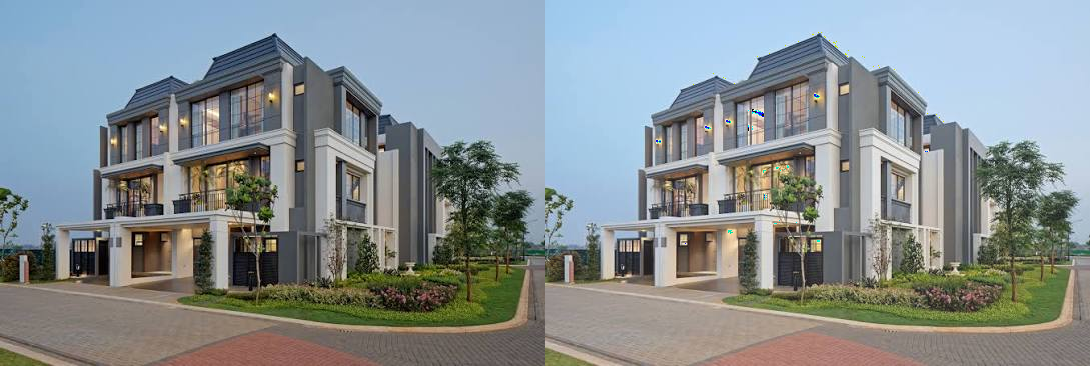

In [ ]:
print('Mengubah tingkat kecerahan citra')
print('----------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')


original = cv.imread('/content/drive/MyDrive/PCVK2026/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)


for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(
                original[y, x, c] + brightness, 0, 255
            )



final_frame = cv.hconcat((original, brightness_image))

cv2_imshow(final_frame)

## **TUGAS PRAKTIKUM**

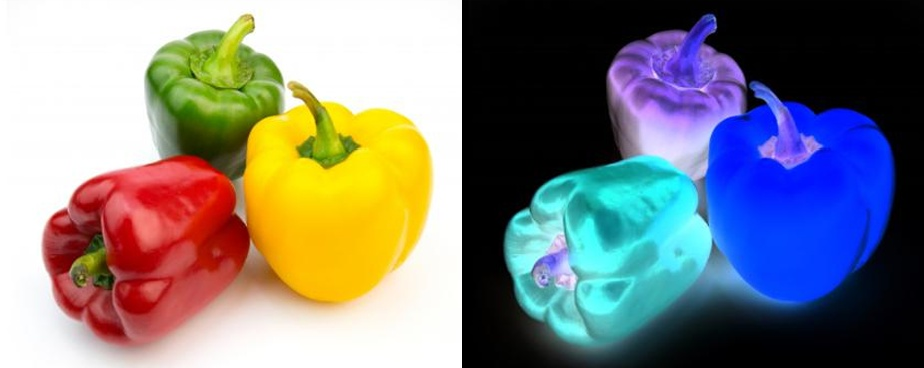

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow


original = cv.imread('/content/drive/MyDrive/PCVK2026/paprika.jpg')


inverse_image = np.zeros(original.shape, original.dtype)


for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            inverse_image[y, x, c] = 255 - original[y, x, c]

final_frame = cv.hconcat((original, inverse_image))

cv2_imshow(final_frame)

## 2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga menghasilkan keluaran seperti berikut:


Mengubah kontras dan tingkat kecerahan citra
---------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


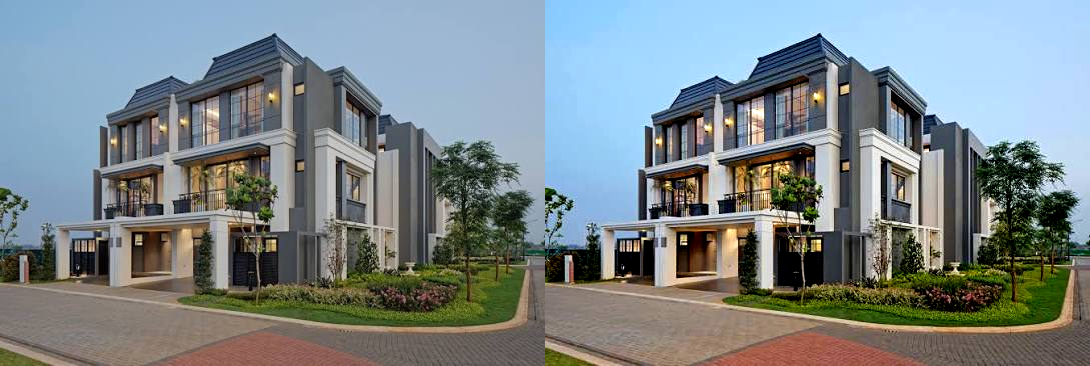

In [ ]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('---------------------------------------------')

try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')

# Membaca citra
original = cv.imread(
    '/content/drive/MyDrive/PCVK2026/houses.jpg'
)

# Membuat array kosong untuk hasil
contrast_image = np.zeros(original.shape, original.dtype)

# Rumus contrast dan brightness
# g = contrast * (f - 128) + 128 + brightness

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):

            contrast_image[y, x, c] = np.clip(
                contrast * (int(original[y, x, c]) - 128)
                + 128
                + brightness,
                0,
                255
            )

# Menampilkan gambar asli dan hasil berdampingan
final_frame = cv.hconcat((original, contrast_image))

cv2_imshow(final_frame)

## 3.Implementasikan transformasi logarithmic brightness pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi log, sehingga menghasilkan keluaran seperti berikut:

Mengubah tingkat kecerahan citra dengan Transformasi Log
---------------------------------------------------------
Masukkan nilai kecerahan: 50


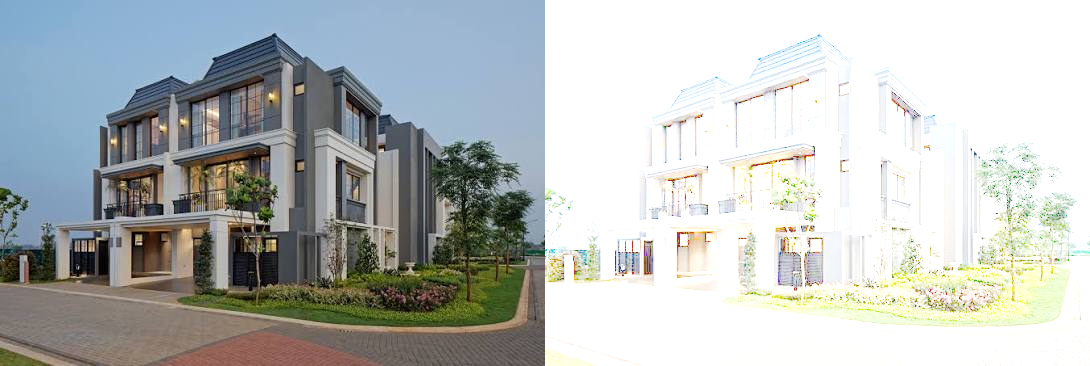

In [ ]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('---------------------------------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

# Membaca citra
original = cv.imread(
    '/content/drive/MyDrive/PCVK2026/houses.jpg'
)

# Membuat array kosong
log_image = np.zeros(original.shape, original.dtype)

# Konstanta transformasi log
c = 255 / np.log(256)

# Proses setiap piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for ch in range(original.shape[2]):

            # Rumus transformasi log
            value = c * np.log(
                1 + int(original[y, x, ch])
            )

            # Tambahkan brightness
            value = value + brightness

            # Batasi nilai piksel 0-255
            log_image[y, x, ch] = np.clip(
                value,
                0,
                255
            )

# Menampilkan gambar asli dan hasil berdampingan
final_frame = cv.hconcat((original, log_image))

cv2_imshow(final_frame)

### 4. mplementasikan transformasi grayscale menggunakan metode averaging, lightness, dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

#### a. Averaging

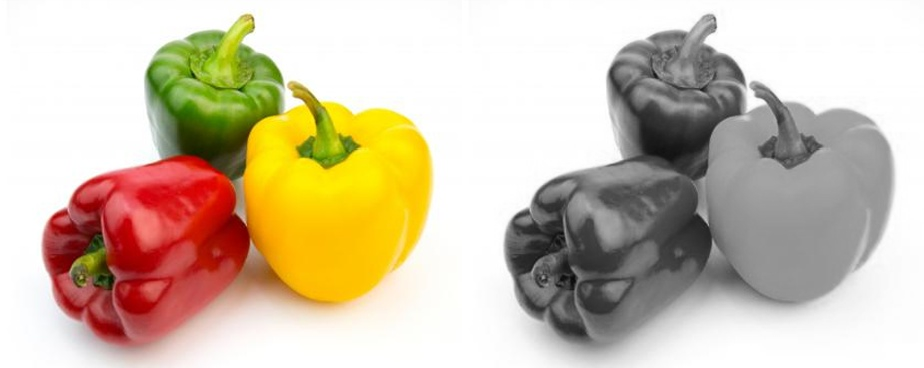

In [ ]:
original = cv.imread(
    '/content/drive/MyDrive/PCVK2026/paprika.jpg'
)

averaging = np.zeros(original.shape[:2], dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):

        B = int(original[y, x, 0])
        G = int(original[y, x, 1])
        R = int(original[y, x, 2])

        averaging[y, x] = (R + G + B) / 3

averaging_bgr = cv.cvtColor(averaging, cv.COLOR_GRAY2BGR)

final_frame = cv.hconcat((original, averaging_bgr))

cv2_imshow(final_frame)

#### b. Lightness

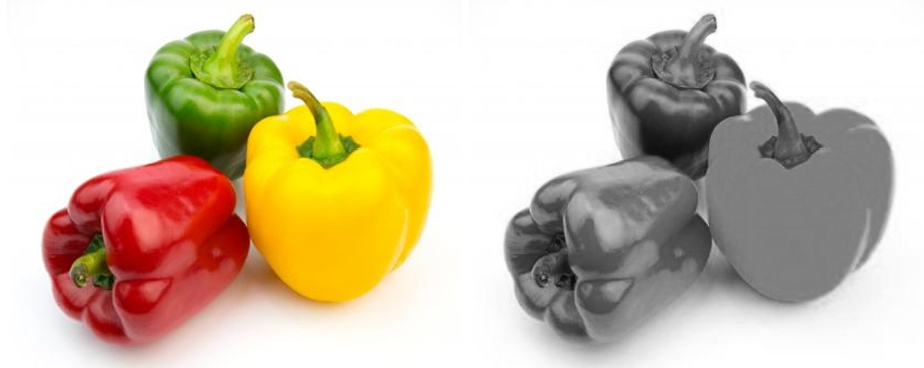

In [ ]:
original = cv.imread(
    '/content/drive/MyDrive/PCVK2026/paprika.jpg'
)

lightness = np.zeros(original.shape[:2], dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):

        B = int(original[y, x, 0])
        G = int(original[y, x, 1])
        R = int(original[y, x, 2])

        maximum = max(R, G, B)
        minimum = min(R, G, B)

        lightness[y, x] = (maximum + minimum) / 2

lightness_bgr = cv.cvtColor(lightness, cv.COLOR_GRAY2BGR)

final_frame = cv.hconcat((original, lightness_bgr))

cv2_imshow(final_frame)

#### c. Luminance

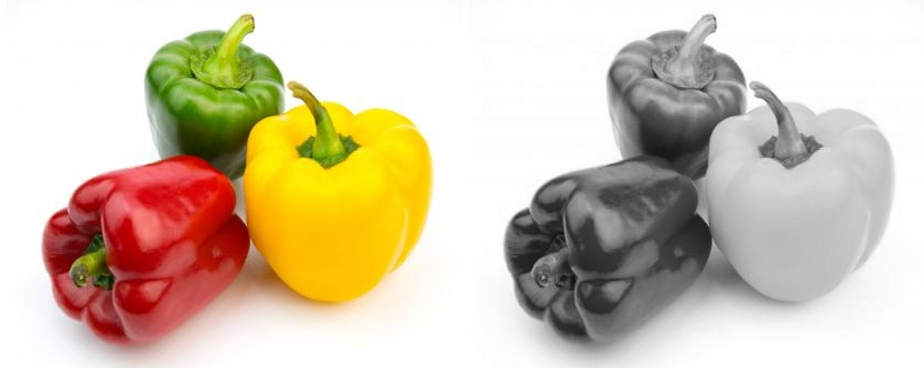

In [ ]:
original = cv.imread(
    '/content/drive/MyDrive/PCVK2026/paprika.jpg'
)

luminance = np.zeros(original.shape[:2], dtype=np.uint8)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):

        B = int(original[y, x, 0])
        G = int(original[y, x, 1])
        R = int(original[y, x, 2])

        luminance[y, x] = (
            0.299 * R +
            0.587 * G +
            0.114 * B
        )

luminance_bgr = cv.cvtColor(luminance, cv.COLOR_GRAY2BGR)

final_frame = cv.hconcat((original, luminance_bgr))

cv2_imshow(final_frame)

### 5.


#### Merah

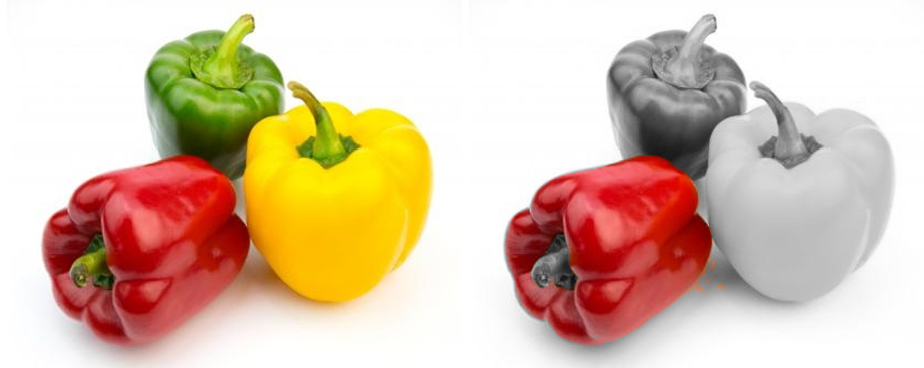

In [ ]:
# Membaca citra
original = cv.imread(
    '/content/drive/MyDrive/PCVK2026/paprika.jpg'
)

# Konversi BGR ke HSV
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# Range warna merah
lower_red1 = np.array([0, 100, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 100, 50])
upper_red2 = np.array([180, 255, 255])

# Membuat mask merah
mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)

mask = mask1 + mask2

# Membuat grayscale
gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

# Ubah grayscale menjadi BGR
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Pertahankan warna merah
hasil_merah = gray_bgr.copy()
hasil_merah[mask > 0] = original[mask > 0]

# Tampilkan citra asli dan hasil
final_frame = cv.hconcat((original, hasil_merah))

cv2_imshow(final_frame)

#### hijau

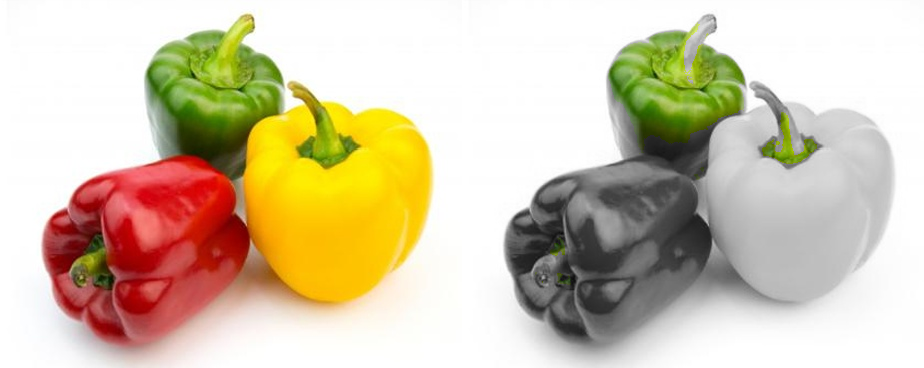

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

# Membaca citra
original = cv.imread(
    '/content/drive/MyDrive/PCVK2026/paprika.jpg'
)

# Konversi BGR ke HSV
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# Range warna hijau
lower_green = np.array([35, 70, 50])
upper_green = np.array([85, 255, 255])

# Membuat mask hijau
mask = cv.inRange(hsv, lower_green, upper_green)

# Membuat grayscale
gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

# Ubah grayscale menjadi BGR
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Pertahankan warna hijau
hasil_hijau = gray_bgr.copy()
hasil_hijau[mask > 0] = original[mask > 0]

# Tampilkan citra asli dan hasil
final_frame = cv.hconcat((original, hasil_hijau))

cv2_imshow(final_frame)

#### kuning

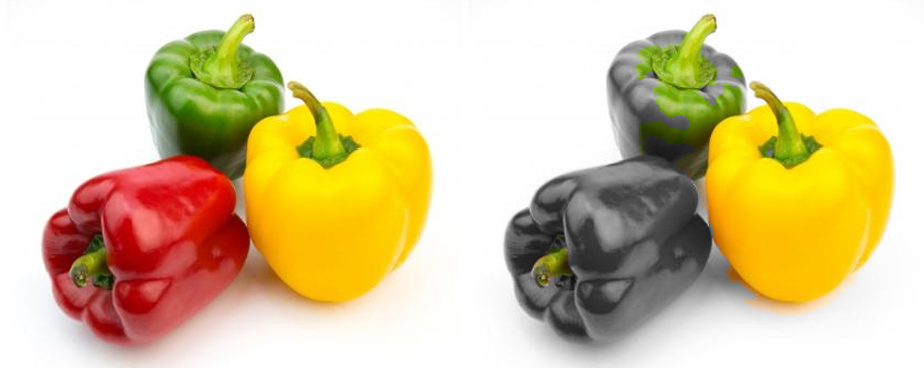

In [ ]:
# Membaca citra
original = cv.imread(
    '/content/drive/MyDrive/PCVK2026/paprika.jpg'
)

# Konversi BGR ke HSV
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# Range warna kuning yang diperlebar
lower_yellow = np.array([15, 50, 50])
upper_yellow = np.array([40, 255, 255])

# Membuat mask kuning
mask = cv.inRange(hsv, lower_yellow, upper_yellow)

# Membersihkan mask agar area kuning lebih utuh
kernel = np.ones((5, 5), np.uint8)

mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)

# Membuat grayscale
gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

# Ubah grayscale menjadi BGR
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Pertahankan warna kuning
hasil_kuning = gray_bgr.copy()
hasil_kuning[mask > 0] = original[mask > 0]

# Tampilkan citra asli dan hasil berdampingan
final_frame = cv.hconcat((original, hasil_kuning))

cv2_imshow(final_frame)

## 6. Buat Gamma Correction sesuai dengan petunjuk berikut

Gamma Correction pada citra
----------------------------------
Masukkan nilai Gamma: 0.3


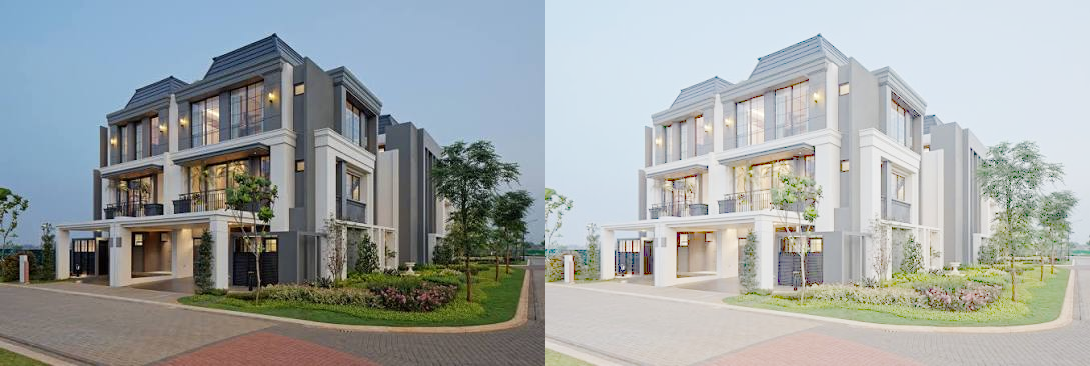

In [ ]:
print('Gamma Correction pada citra')
print('----------------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

# Membaca citra
original = cv.imread(
    '/content/drive/MyDrive/PCVK2026/houses.jpg'
)

# Membuat array kosong untuk hasil gamma correction
gamma_image = np.zeros(original.shape, original.dtype)

# Gamma Correction
# Rumus:
# Iout = 255 * (Iin / 255)^gamma

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):

            gamma_image[y, x, c] = 255 * (
                (original[y, x, c] / 255) ** gamma
            )

# Menampilkan citra asli dan hasil gamma correction berdampingan
final_frame = cv.hconcat((original, gamma_image))

cv2_imshow(final_frame)

## 7. Buat Simulasi Image Depth


Simulasi Image Depth
----------------------------------
Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8

Grayscale 8-bit


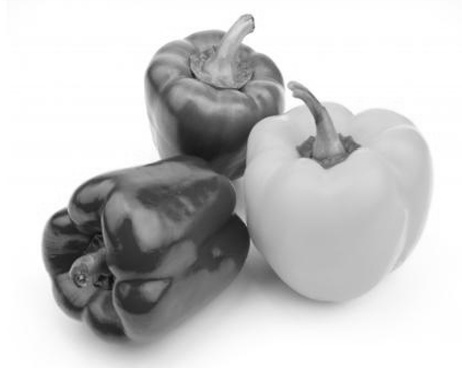

Grayscale 3-bit


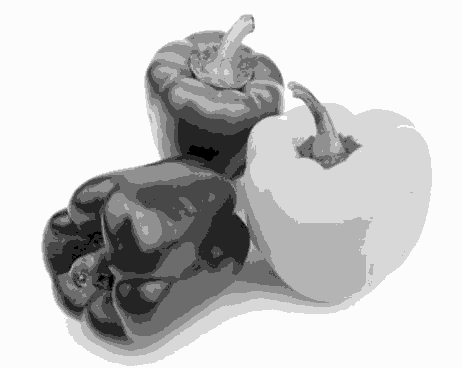

In [ ]:

print('Simulasi Image Depth')
print('----------------------------------')

try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))

    if bit_depth < 1 or bit_depth > 8:
        print('Bit depth harus antara 1-8')
    else:

        # Bit depth awal
        original_bit_depth = 8

        # Jumlah level berdasarkan bit depth
        levels = 2 ** bit_depth

        print('Bit depth awal  : 8 bit')
        print('Bit depth tujuan: ' + str(bit_depth) + ' bit')
        print('Jumlah level    : ' + str(levels))

        # Membaca citra grayscale
        original = cv.imread(
            '/content/drive/MyDrive/PCVK2026/paprika.jpg',
            cv.IMREAD_GRAYSCALE
        )

        # Membuat array hasil
        depth_image = np.zeros(
            original.shape,
            original.dtype
        )

        # Simulasi image depth
        for y in range(original.shape[0]):
            for x in range(original.shape[1]):

                # Kuantisasi nilai piksel
                depth_image[y, x] = (
                    original[y, x] // (256 // levels)
                ) * (255 // (levels - 1))

        # Menampilkan gambar
        print('\nGrayscale 8-bit')
        cv2_imshow(original)

        print('Grayscale ' + str(bit_depth) + '-bit')
        cv2_imshow(depth_image)

except ValueError:
    print('Error, not a number')

## 8. Buat modul Average Denoising